<a href="https://colab.research.google.com/github/esraamosalman22-arch/activity-3/blob/main/activity_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

#Load Iris dataset

In [4]:

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#EDA

In [10]:

print(df.isnull().sum())


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [20]:
# First 5 rows
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [13]:
# Shape of dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (150, 4)


In [14]:
# Column names
print("Columns:")
print(df.columns)



Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


In [16]:
# Data types
print(df.dtypes)


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object




#Preprocessing



In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#PCA

In [21]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(
"Variance Retained:",
sum(pca.explained_variance_ratio_)
)

Variance Retained: 0.9581320720000166


PCA Plot

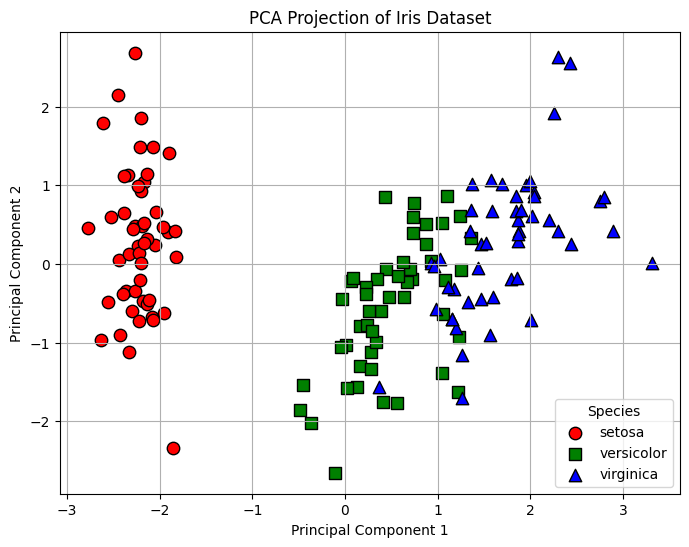

In [22]:
plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']
markers = ['o', 's', '^']

for i, target_name in enumerate(iris.target_names):
    plt.scatter(
        X_pca[iris.target == i, 0],
        X_pca[iris.target == i, 1],
        color=colors[i],
        marker=markers[i],
        s=80,
        edgecolors='black',
        label=target_name
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Iris Dataset")

plt.legend(title="Species")
plt.grid(True)

plt.show()

#DBSCAN Original

In [ ]:
db_original=DBSCAN(
eps=1.1,
min_samples=5
)

labels_original=db_original.fit_predict(
X_scaled
)

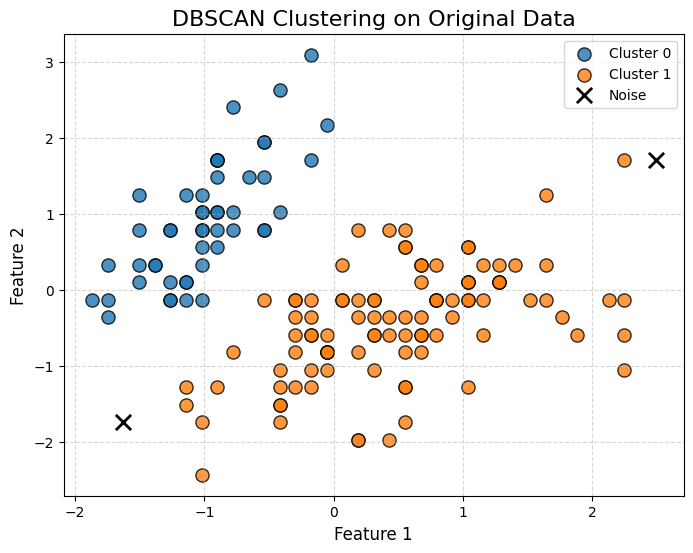

In [ ]:
plt.figure(figsize=(8,6))

for cluster in set(labels_original):

    points = X_scaled[labels_original == cluster]

    if cluster == -1:
        plt.scatter(
            points[:,0],
            points[:,1],
            color='black',
            marker='x',
            s=120,
            linewidths=2,
            label='Noise'
        )


    else:
        plt.scatter(
            points[:,0],
            points[:,1],
            s=90,
            edgecolors='black',
            alpha=0.8,
            label=f'Cluster {cluster}'
        )

plt.title("DBSCAN Clustering on Original Data", fontsize=16)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#DBSCAN after PCA

In [ ]:
db_pca=DBSCAN(
eps=0.8,
min_samples=5
)

labels_pca=db_pca.fit_predict(
X_pca
)

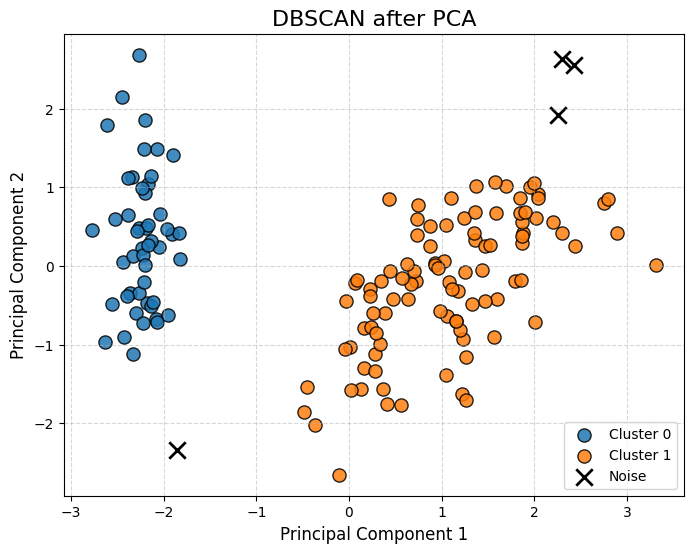

In [ ]:
plt.figure(figsize=(8,6))

for cluster in set(labels_pca):

    points = X_pca[labels_pca == cluster]

    if cluster == -1:
        plt.scatter(
            points[:,0],
            points[:,1],
            color='black',
            marker='x',
            s=140,
            linewidths=2,
            label='Noise'
        )

    else:
        plt.scatter(
            points[:,0],
            points[:,1],
            s=90,
            edgecolors='black',
            alpha=0.85,
            label=f'Cluster {cluster}'
        )

plt.title("DBSCAN after PCA", fontsize=16)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
def analyze(labels,name):

    clusters=len(
        set(labels)
    )-(1 if -1 in labels else 0)

    noise=list(labels).count(-1)

    print(name)
    print("Clusters:",clusters)
    print("Noise:",noise)
    print()

In [ ]:
analyze(
labels_original,
"Original Data"
)

analyze(
labels_pca,
"PCA Data"
)

Original Data
Clusters: 2
Noise: 2

PCA Data
Clusters: 2
Noise: 4



In [ ]:
if len(set(labels_pca))>1:

    score=silhouette_score(
        X_pca,
        labels_pca
    )

    print(
    "Silhouette:",
    round(score,3)
    )

Silhouette: 0.558


#parameter tuning on the original data

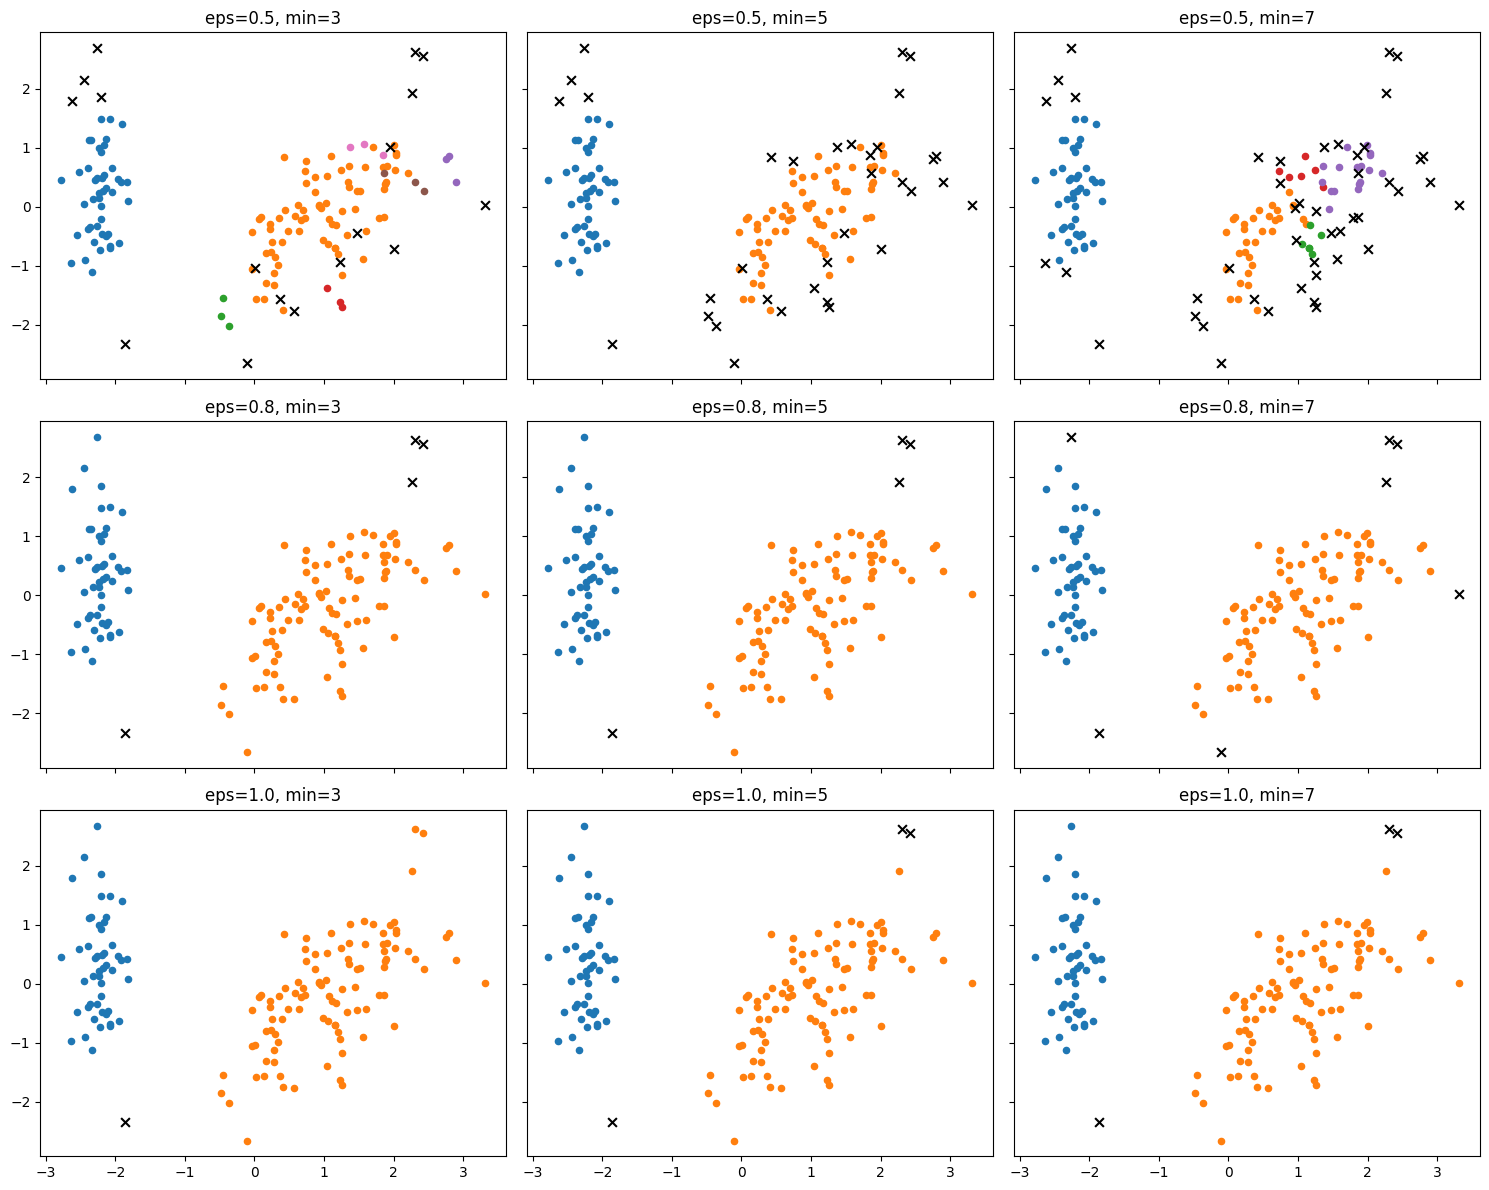

Best Parameters Found:
eps = 1.0
min_samples = 5
silhouette = 0.5382884306788227


In [ ]:
eps_values = [0.5, 0.8, 1.0]
min_samples_values = [3, 5, 7]

results = []

fig, axes = plt.subplots(
    len(eps_values),
    len(min_samples_values),
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

best_score = -1
best_params = None
best_labels = None

for i, eps_val in enumerate(eps_values):
    for j, min_s_val in enumerate(min_samples_values):

        db = DBSCAN(eps=eps_val, min_samples=min_s_val)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1

        results.append([eps_val, min_s_val, n_clusters, n_noise, score])

        if score > best_score:
            best_score = score
            best_params = (eps_val, min_s_val)
            best_labels = labels

        current_ax = axes[i, j]

        unique_labels = set(labels)

        for label in unique_labels:
            if label == -1:
                current_ax.scatter(
                    X_2d[labels == label, 0],
                    X_2d[labels == label, 1],
                    c="black",
                    marker="x",
                    s=40
                )
            else:
                current_ax.scatter(
                    X_2d[labels == label, 0],
                    X_2d[labels == label, 1],
                    s=20
                )

        current_ax.set_title(f"eps={eps_val}, min={min_s_val}")


plt.tight_layout()
plt.show()


df_results = pd.DataFrame(results, columns=[
    "eps", "min_samples", "n_clusters", "noise_points", "silhouette_score"
])

print("Best Parameters Found:")
print("eps =", best_params[0])
print("min_samples =", best_params[1])
print("silhouette =", best_score)


#parameter tuning on data after pca

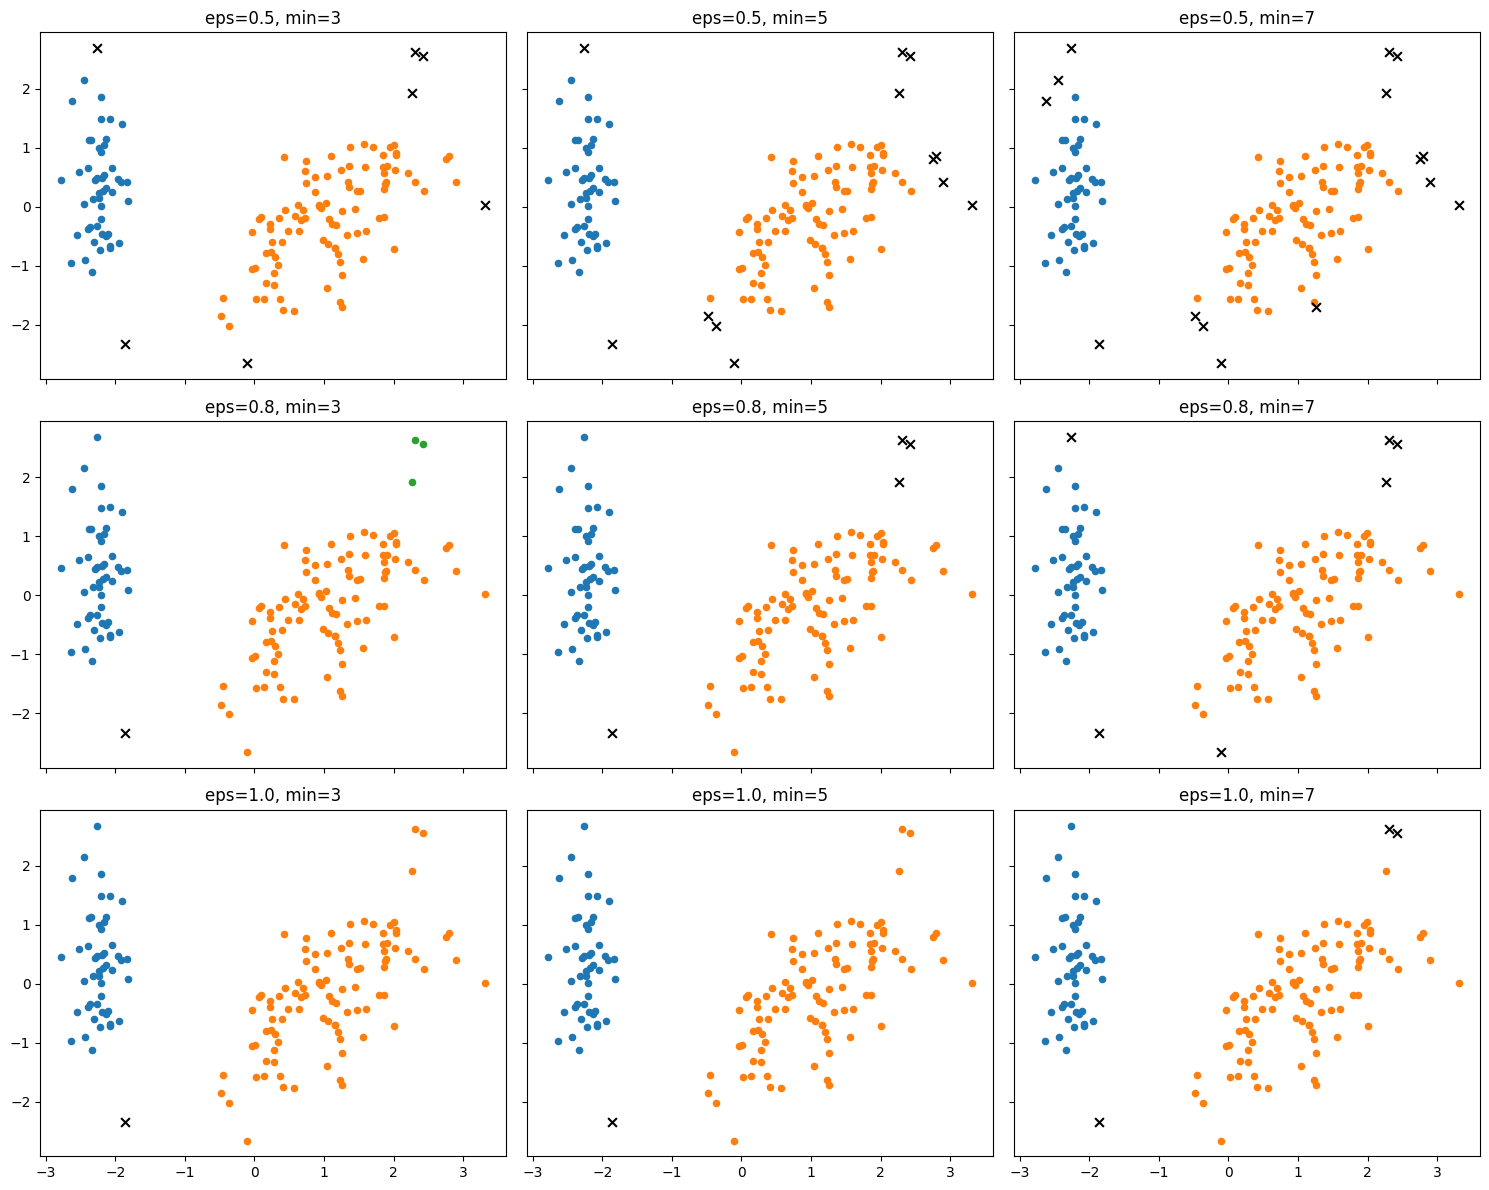

Best Parameters Found:
eps = 1.0
min_samples = 7
silhouette = 0.5722013605630372


In [ ]:
eps_values = [0.5, 0.8, 1.0]
min_samples_values = [3, 5, 7]

results = []

fig, axes = plt.subplots(
    len(eps_values),
    len(min_samples_values),
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

best_score = -1
best_params = None
best_labels = None

for i, eps_val in enumerate(eps_values):
    for j, min_s_val in enumerate(min_samples_values):

        db = DBSCAN(eps=eps_val, min_samples=min_s_val)
        labels = db.fit_predict(X_pca)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            score = silhouette_score(X_pca, labels)
        else:
            score = -1

        results.append([eps_val, min_s_val, n_clusters, n_noise, score])

        if score > best_score:
            best_score = score
            best_params = (eps_val, min_s_val)
            best_labels = labels

        current_ax = axes[i, j]

        unique_labels = set(labels)

        for label in unique_labels:
            if label == -1:
                current_ax.scatter(
                    X_pca[labels == label, 0],
                    X_pca[labels == label, 1],
                    c="black",
                    marker="x",
                    s=40
                )
            else:
                current_ax.scatter(
                    X_pca[labels == label, 0],
                    X_pca[labels == label, 1],
                    s=20
                )

        current_ax.set_title(f"eps={eps_val}, min={min_s_val}")



plt.tight_layout()
plt.show()


df_results = pd.DataFrame(results, columns=[
    "eps", "min_samples", "n_clusters", "noise_points", "silhouette_score"
])

print("Best Parameters Found:")
print("eps =", best_params[0])
print("min_samples =", best_params[1])
print("silhouette =", best_score)

#Final comparisons

In [ ]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def run_dbscan(X, eps, min_samples):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)

    if clusters > 1:
        score = silhouette_score(X, labels)
    else:
        score = -1

    return clusters, noise, score


cases = [
    ("Original", "Before Tuning", X_scaled, 1.1, 5),
    ("Original", "After Tuning", X_scaled, 1.0, 5),
    ("PCA", "Before Tuning", X_pca, 0.8, 5),
    ("PCA", "After Tuning", X_pca, 1.0, 7),
]

results = []

for data_type, stage, X, eps, min_s in cases:

    clusters, noise, score = run_dbscan(X, eps, min_s)

    results.append([
        data_type,
        stage,
        eps,
        min_s,
        clusters,
        noise,
        score
    ])


df_results = pd.DataFrame(results, columns=[
    "Data Type",
    "Stage",
    "eps",
    "min_samples",
    "Clusters",
    "Noise Points",
    "Silhouette Score"
])

print(df_results)

  Data Type          Stage  eps  min_samples  Clusters  Noise Points  \
0  Original  Before Tuning  1.1            5         2             2   
1  Original   After Tuning  1.0            5         2             3   
2       PCA  Before Tuning  0.8            5         2             4   
3       PCA   After Tuning  1.0            7         2             3   

   Silhouette Score  
0          0.551772  
1          0.538288  
2          0.557590  
3          0.572201  
